# Analisis Review Google Play - MyIM3
## NLP Pipeline: Preprocessing, Stopword Removal(customisasi stop word), dan Frekuensi Kata

In [8]:
# Install library yang dibutuhkan
!pip install google_play_scraper textblob seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
import re
import io
import pickle
import time
import datetime
import os
from pathlib import Path
from collections import Counter

import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import sklearn

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

# Download resource NLTK
nltk.download('stopwords', quiet=True)

print('Semua library berhasil diimport!')


Semua library berhasil diimport!


## 1. Upload Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [110]:
# file berupa .parquet karena kalo csv size nya besar
import pandas as pd

file_path = "/content/drive/MyDrive/dataset/hasil_crawling_myim3_versi_indonesia.parquet"

df_myim3rev = pd.read_parquet(file_path)

print(f"Berhasil memuat Parquet ({df_myim3rev.shape[0]} baris, {df_myim3rev.shape[1]} kolom)")

Berhasil memuat Parquet (2701160 baris, 11 kolom)


## 2. Preview Dataset

In [112]:
# Tampilkan kolom yang relevan saja
cols_to_show = ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']
cols_available = [c for c in cols_to_show if c in df_myim3rev.columns]
display(df_myim3rev[cols_available].head(10))


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,bagus untuk di coba,5,0,82.13.0,2026-04-17 05:39:19,None,None
1,aplikasi ini sangat membantu dn kuota ny pun m...,5,0,nan,2026-04-17 05:38:08,None,None
2,"aplikasi ga guna, pulsa saya cukup tapi selalu...",1,0,82.13.1,2026-04-17 05:23:08,"Selamat sore Bapak Syaiful, maaf sebelumnya. S...",2026-04-17 09:08:05
3,ga rekomendasi,1,0,nan,2026-04-17 05:16:45,"Selamat sore Pelanggan IM3, mohon maaf atas pe...",2026-04-17 08:52:16
4,bagus,5,0,82.13.1,2026-04-17 05:00:55,None,None
5,bagus cuman kuotanya nangung' marketing semua,5,0,82.13.1,2026-04-17 04:40:32,None,None
6,gg pol,5,0,82.13.1,2026-04-17 04:29:17,None,None
7,mantap,5,0,82.13.0,2026-04-17 04:28:30,None,None
8,"fitur satspam,tapi pengguna malah di spam pop ...",2,0,82.13.0,2026-04-17 04:20:41,"Hi Kak, maaf untuk hal yang dialami. Kami akan...",2022-06-04 19:35:43
9,sangat bagus,5,0,82.13.1,2026-04-17 04:19:10,None,None


In [113]:
df_myim3rev.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2701160 entries, 0 to 2701159
Data columns (total 11 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   reviewId              object
 1   userName              object
 2   userImage             object
 3   content               object
 4   score                 int64 
 5   thumbsUpCount         int64 
 6   reviewCreatedVersion  object
 7   at                    object
 8   replyContent          object
 9   repliedAt             object
 10  appVersion            object
dtypes: int64(2), object(9)
memory usage: 226.7+ MB


## 3. Stopword Removal

### 3a. Indonesian Stopwords (NLTK)
Menggunakan daftar stopwords Bahasa Indonesia dari library NLTK sebagai basis.

In [114]:
# Load Indonesian stopwords dari NLTK
indonesian_stopwords = set(stopwords.words('indonesian'))
print(f'Jumlah stopwords NLTK Indonesia: {len(indonesian_stopwords)}')
print('\nContoh 20 stopwords pertama:')
print(sorted(list(indonesian_stopwords))[:20])


Jumlah stopwords NLTK Indonesia: 757

Contoh 20 stopwords pertama:
['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


### 3b. Custom Stopwords Tambahan

Kata-kata berikut **tidak ditemukan** di daftar NLTK namun sering muncul di ulasan dan **tidak memiliki makna penting** dalam konteks analisis sentimen. Kata-kata ini ditambahkan secara manual berdasarkan hasil eksplorasi *frequent words*.

Kategori custom stopwords:
- **Bahasa gaul / singkatan informal**: `ga`, `gak`, `gk`, `nggak`, `ngga`, `nggk`,`ya`
- **Kata filler**: `aja`, `udah`, `udh`, `dah`, `kayak`, `emang`, `sih`, `dong`, `deh`, `nih`, `loh`, `yah`
- **Singkatan umum**: `yg`, `dgn`, `krn`, `utk`, `tdk`, `hrs`, `bisa`, `sdh`, `blm`, `tp`, `dr`,`bgt`
- **Angka & simbol**: karakter non-huruf
- **Kata netral tanpa nilai sentimen**: `app`, `aplikasi`, `myim3`, `im3`, `appnya`, `aplikasinya`
- **Kata transisional**: `juga`, `sudah`, `kalau`, `karena`, `kalau`, `seperti`, `banget`, `sangat`
  *(sudah sebagian ada di NLTK, ditambahkan sebagai jaring pengaman)*

In [115]:
# ============================================================
# CUSTOM STOPWORDS - Kata tidak bermakna dari hasil frequent words
# Tambahkan atau hapus kata sesuai kebutuhan analisis
# ============================================================

custom_stopwords = {
    'ga', 'gak', 'gk', 'ngga', 'nggak', 'nggk', 'kagak', 'enggak',
    'ya','ok','im','oke','gua','gw','mulu',

    'aja', 'doang', 'sih', 'dong', 'deh', 'nih', 'loh', 'nah',
    'yah', 'wah', 'mah', 'tuh', 'kan', 'kok',

    'udah', 'udh', 'dah', 'sdh', 'blm', 'belom',
    'emang', 'memang', 'kayak', 'kaya', 'kek', 'gitu', 'gini',
    'bgt','beli', 'kasih', 'bintang', 'masuk', 'buka', 'isi',
    'cek', 'semoga', 'mohon', 'terimakasih', 'makasih','pake','kali', 'main', 'terima', 'bikin', 'coba',
    'dapet', 'ganti', 'gimana','kadang', 'daerah', 'pengguna', 'download',
    'rb','harga', 'promo', 'gratis', 'bonus', 'game','hilang','ilang','tolong',

    'yg',
    'dgn', 'dg', 'krn', 'karna', 'utk', 'tdk', 'hrs',
    'tp', 'tpi', 'ttg', 'dr', 'pd', 'dlm', 'sm', 'jd', 'jdi',
    'lg', 'lgi', 'jg', 'juga', 'sdg', 'spy', 'bnyk', 'byk',

    'myim3', 'im3', 'app', 'aplikasi', 'appnya', 'aplikasinya',
    'apk', 'apknya','myim','indosat','my', 'gb', 'kartu', 'data', 'internet', 'aplikasi', 'paket', 'pulsa', 'kuota','kouta','jaringan','jaringannya','pakai','sinyal','sinyalnya','paketan','signal',

    'kalo', 'kalau', 'klo', 'klu', 'sama', 'pas', 'buat',
    'biar', 'supaya', 'terus', 'trus', 'habis', 'abis', 'abisnya',
    'banget', 'sangat',

    'ada', 'itu', 'ini', 'nya', 'yang', 'di', 'ke', 'dari',
    'dengan', 'dan', 'atau', 'untuk', 'pada', 'tidak', 'bisa',
    'akan', 'juga', 'sudah', 'belum', 'bisa', 'lebih', 'lagi',
    'masih', 'seperti', 'saat', 'setelah', 'kalau', 'karena','langsung', 'update', 'pelanggan', 'hp',
    'tau', 'min', 'provider', 'sisa', 'sms', 'login', 'jam', 'operator',
    'kualitas', 'pelayanan','unlimited','mending','sy','nih','ni','ko','the', 'in', 'is', 'ny', 'ku', 'si', 'an', 'aj',
    'orang', 'kota', 'jam', 'malam', 'hujan',
    'daftar', 'kode', 'job', 'eh', 'up', 'the', 'ny', 'youtube',
    'cs', 'apl', 'apps', 'wa',

    '1', '2', '3', '4', '5', '0',
}

# Gabungkan NLTK + custom stopwords
all_stopwords = indonesian_stopwords.union(custom_stopwords)

# Cek kata custom yang belum ada di NLTK
new_words = custom_stopwords - indonesian_stopwords
print(f'Jumlah stopwords NLTK           : {len(indonesian_stopwords)}')
print(f'Jumlah custom stopwords         : {len(custom_stopwords)}')
print(f'Kata custom BARU (tidak di NLTK): {len(new_words)}')
print(f'Total stopwords gabungan        : {len(all_stopwords)}')
print(f'\nKata custom baru yang ditambahkan:')
print(sorted(new_words))
print('----------------------------------------------------')

Jumlah stopwords NLTK           : 757
Jumlah custom stopwords         : 215
Kata custom BARU (tidak di NLTK): 177
Total stopwords gabungan        : 934

Kata custom baru yang ditambahkan:
['0', '1', '2', '3', '4', '5', 'abis', 'abisnya', 'aj', 'aja', 'an', 'apk', 'apknya', 'apl', 'aplikasi', 'aplikasinya', 'app', 'appnya', 'apps', 'banget', 'beli', 'belom', 'bgt', 'biar', 'bikin', 'bintang', 'blm', 'bnyk', 'bonus', 'buka', 'byk', 'cek', 'coba', 'cs', 'daerah', 'daftar', 'dah', 'dapet', 'data', 'deh', 'dg', 'dgn', 'dlm', 'doang', 'download', 'dr', 'eh', 'emang', 'ga', 'gak', 'game', 'ganti', 'gb', 'gimana', 'gini', 'gitu', 'gk', 'gratis', 'gua', 'gw', 'habis', 'harga', 'hilang', 'hp', 'hrs', 'hujan', 'ilang', 'im', 'im3', 'in', 'indosat', 'internet', 'is', 'isi', 'jam', 'jaringan', 'jaringannya', 'jd', 'jdi', 'jg', 'job', 'kadang', 'kagak', 'kali', 'kalo', 'karna', 'kartu', 'kasih', 'kaya', 'kayak', 'kek', 'klo', 'klu', 'ko', 'kode', 'kota', 'kouta', 'krn', 'ku', 'kualitas', 'kuota', 'l

### 3c. Fungsi Preprocessing Teks
Preprocessing mencakup: lowercase → hapus karakter non-huruf → tokenisasi → stopword removal.

In [116]:
def preprocess_text(text, stopwords_set):
    """
    Preprocessing teks:
    1. Lowercase
    2. Hapus angka dan tanda baca
    3. Hapus spasi berlebih
    4. Tokenisasi
    5. Filter stopwords
    6. Filter kata pendek (< 2 huruf)
    """
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # hapus non-huruf
    text = re.sub(r'\s+', ' ', text).strip() # normalisasi spasi
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_set and len(t) > 1]
    return tokens

# Test fungsi
sample = 'Gak bisa login ke app myim3, udah coba berkali2 tetap error! yg'
result = preprocess_text(sample, all_stopwords)
print(f'Input  : {sample}')
print(f'Output : {result}')


Input  : Gak bisa login ke app myim3, udah coba berkali2 tetap error! yg
Output : ['berkali', 'error']


## 4. Analisis Frekuensi Kata

In [117]:
text_column = 'content'

# Terapkan preprocessing ke seluruh data
all_tokens = []
for text in df_myim3rev[text_column].dropna():
    all_tokens.extend(preprocess_text(text, all_stopwords))

# Hitung frekuensi
word_counts = Counter(all_tokens)
common_words = word_counts.most_common(30)

# Tampilkan sebagai DataFrame
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
display(word_freq_df)

print(f'\nTotal token setelah preprocessing : {len(all_tokens)}')
print(f'Jumlah kata unik                  : {len(word_counts)}')


,Word,Frequency
0,bagus,412188
1,mantap,205167
2,good,123210
3,membantu,103371
4,lemot,71596
5,suka,70898
6,jelek,60339
7,puas,58097
8,keren,55990
9,mahal,50698



Total token setelah preprocessing : 6609961
Jumlah kata unik                  : 189365


### Visualisasi Top 30 Kata Paling Sering Muncul

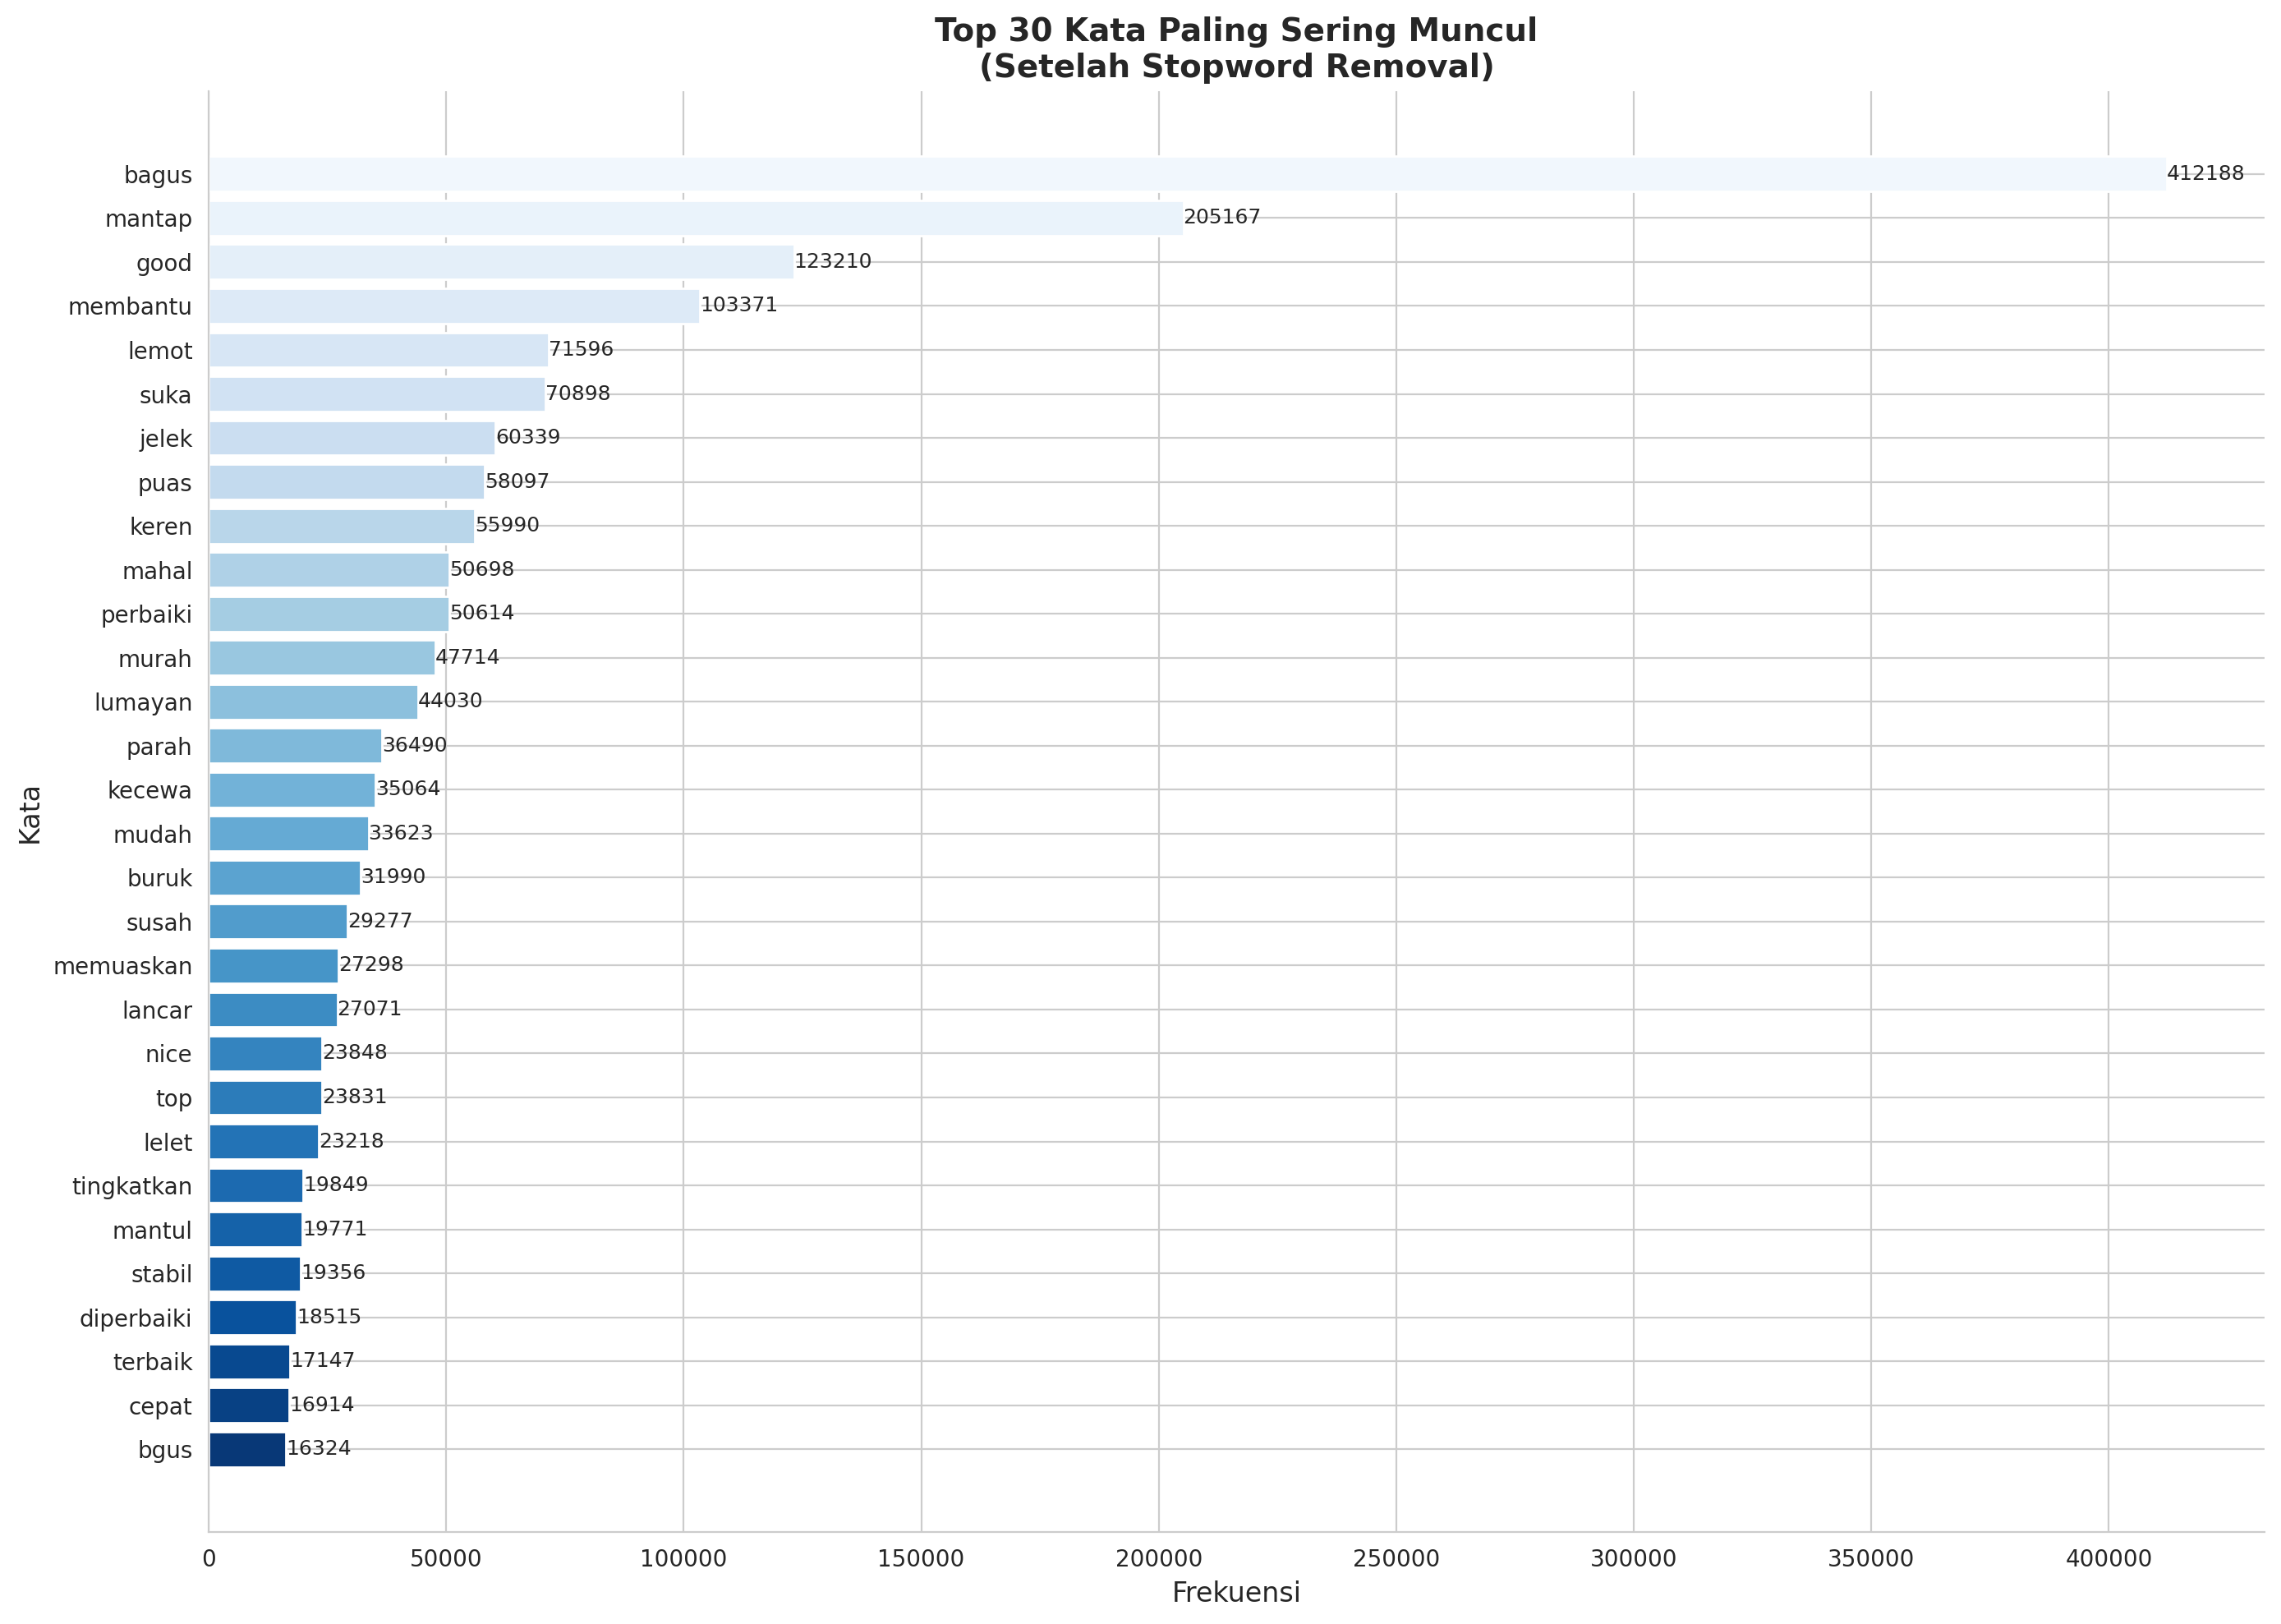

In [118]:
top_n = 30
top_words = word_freq_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(
    top_words['Word'][::-1],
    top_words['Frequency'][::-1],
    color=sns.color_palette('Blues_r', top_n)
)

# Tambahkan label angka di tiap bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', va='center', fontsize=9)

ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_ylabel('Kata', fontsize=12)
ax.set_title(f'Top {top_n} Kata Paling Sering Muncul\n(Setelah Stopword Removal)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Top 50 kata setelah stopword removal




In [119]:
# Preview top 50 untuk review manual
print('Top 50 kata yang tersisa setelah stopword removal:')
for i, (word, freq) in enumerate(word_counts.most_common(50), 1):
    print(f'{i:>3}. {word:<20} {freq}')


Top 50 kata yang tersisa setelah stopword removal:
  1. bagus                412188
  2. mantap               205167
  3. good                 123210
  4. membantu             103371
  5. lemot                71596
  6. suka                 70898
  7. jelek                60339
  8. puas                 58097
  9. keren                55990
 10. mahal                50698
 11. perbaiki             50614
 12. murah                47714
 13. lumayan              44030
 14. parah                36490
 15. kecewa               35064
 16. mudah                33623
 17. buruk                31990
 18. susah                29277
 19. memuaskan            27298
 20. lancar               27071
 21. nice                 23848
 22. top                  23831
 23. lelet                23218
 24. tingkatkan           19849
 25. mantul               19771
 26. stabil               19356
 27. diperbaiki           18515
 28. terbaik              17147
 29. cepat                16914
 30. bgus        